
# CS420 – Artificial Intelligence  
## Project 2: Machine Learning  
### MNIST Dataset Analysis

---

**Dataset:** MNIST Handwritten Digits  
**Task:** Supervised classification using Decision Tree and Neural Network models  

This notebook presents a complete and structured analysis of the MNIST dataset following the official project specifications. All experiments are conducted using the `scikit-learn` library.



## 1. Dataset Preparation

In this section, the MNIST dataset is loaded and split into training, validation, and test sets.  
The original training set is shuffled and divided using a **stratified strategy** with an **80% / 20%** ratio for training and validation, respectively.


**Why preprocessing is necessary**

Although MNIST is a clean dataset, preprocessing is still required to:
- Ensure fair class distribution using stratified sampling
- Normalize pixel values so that optimization-based models (e.g., neural networks) converge faster
- Convert image data into a feature-based representation compatible with classical ML models

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from collections import Counter


In [2]:

# Load MNIST dataset
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
y = y.astype(int)

# Normalize pixel values
X = X / 255.0

# Split original train/test (60k / 10k)
feature_train_full, feature_test, label_train_full, label_test = train_test_split(
    X, y, test_size=1/7, stratify=y, random_state=42
)

# Stratified split train/validation (80/20)
feature_train, feature_val, label_train, label_val = train_test_split(
    feature_train_full, label_train_full,
    test_size=0.2, stratify=label_train_full, random_state=42
)

print("Training set size:", feature_train.shape)
print("Validation set size:", feature_val.shape)
print("Test set size:", feature_test.shape)


Training set size: (48000, 784)
Validation set size: (12000, 784)
Test set size: (10000, 784)



### Visualize a small grid of training images



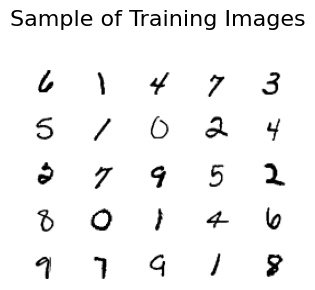

In [3]:
import matplotlib.pyplot as plt

# Create a figure and a 5x5 grid of subplots
fig, axes = plt.subplots(5, 5, figsize=(3, 3))
axes = axes.flatten()

# Display the first 25 training images
for i in range(25):
    # Reshape the 784-pixel image to 28x28 for display
    image = feature_train[i].reshape(28, 28)
    axes[i].imshow(image, cmap='gray_r') # 'gray_r' for white background, black digits
    axes[i].axis('off') # Hide axes

plt.suptitle("Sample of Training Images", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()


### Class Distribution Visualization

The following plots illustrate the class distributions across the original dataset, training set, validation set, and test set.


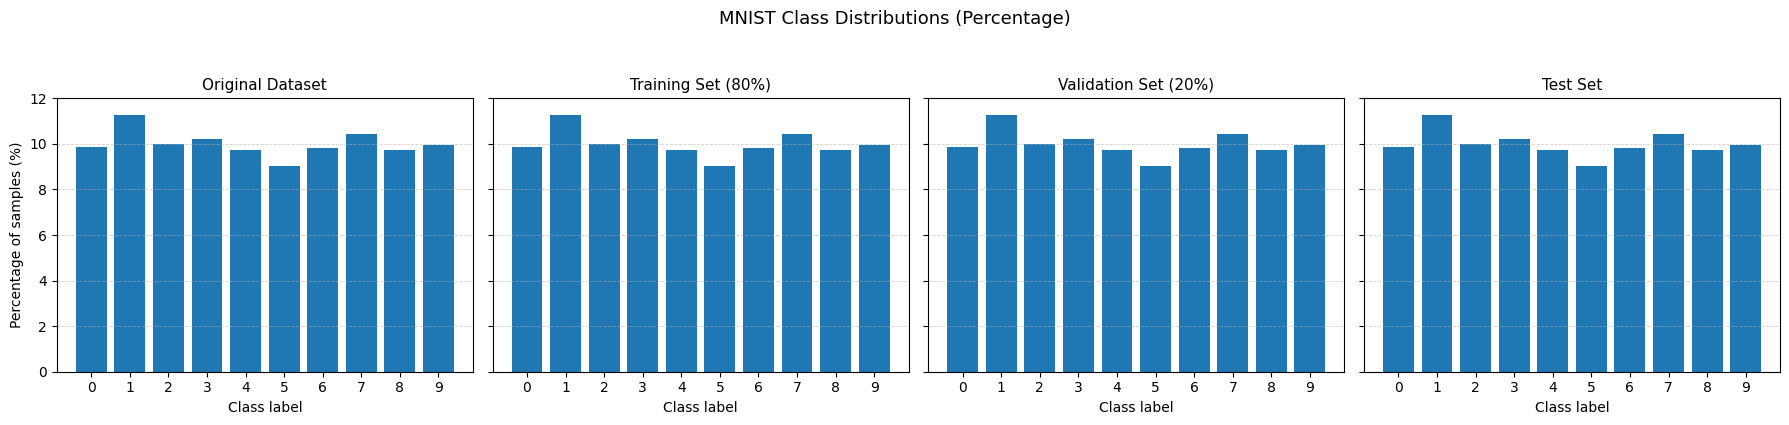

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def plot_distribution_percent(ax, labels, title, n_classes=10, y_max=12):
    classes = np.arange(n_classes)
    c = Counter(labels)
    counts = np.array([c.get(k, 0) for k in classes], dtype=float)
    percents = counts / counts.sum() * 100.0

    ax.bar(classes, percents, width=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Class label")
    ax.set_xticks(classes)
    ax.set_ylim(0, y_max)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# Data + titles
label_sets = [y, label_train, label_val, label_test]
titles = ["Original Dataset", "Training Set (80%)", "Validation Set (20%)", "Test Set"]

# compute a shared y-limit (nice-looking)
all_percents_max = 0
for labels in label_sets:
    c = Counter(labels)
    counts = np.array([c.get(k, 0) for k in range(10)], dtype=float)
    percents = counts / counts.sum() * 100.0
    all_percents_max = max(all_percents_max, percents.max())
y_max = float(np.ceil((all_percents_max + 0.5) * 2) / 2)  # round up to 0.5%

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for ax, labels, title in zip(axes, label_sets, titles):
    plot_distribution_percent(ax, labels, title, n_classes=10, y_max=y_max)

axes[0].set_ylabel("Percentage of samples (%)")
fig.suptitle("MNIST Class Distributions (Percentage)", fontsize=13, y=1.05)
fig.tight_layout()
plt.show()



## 2. Decision Tree Classifier


**Decision Tree with Information Gain**

- We use entropy as the splitting criterion, which corresponds to Information Gain.

- Information Gain represents the expected reduction in entropy after splitting the data on a feature.

- Decision Trees trained with Information Gain tend to create splits that most reduce class uncertainty at each node.

In [5]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(feature_train, label_train)

val_pred = dt.predict(feature_val)
val_acc = accuracy_score(label_val, val_pred)

print("Validation Accuracy (Decision Tree):", val_acc)


Validation Accuracy (Decision Tree): 0.879



### Decision Tree Visualization

Due to the high dimensionality of MNIST (784 features), the tree visualization is limited in interpretability.  
Nevertheless, Graphviz is used to visualize the learned structure.


In [13]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt,
    out_file=None,
    max_depth=None,
    filled=True,
    rounded=True,
)

graphviz.Source(dot_data)


Output hidden; open in https://colab.research.google.com to view.

**Why visualize a shallow tree?**

MNIST has 784 input features (pixels), which leads to very large decision trees.
To ensure readability and avoid visual clutter, we visualize a shallow tree (small max_depth).

This visualization is for interpretability only and does not necessarily represent the best-performing model.

### Create svg file

In [14]:
src = graphviz.Source(dot_data)
svg_path = src.render(filename="mnist_decision_tree", format="svg", cleanup=True)
print("Saved to:", svg_path)

Saved to: mnist_decision_tree.svg



## 3. Hyperparameter Tuning for Decision Tree

**Hyperparameter selection strategy**

The following hyperparameters are tuned using the validation set:
- `max_depth`: controls model complexity
- `min_samples_split`: prevents overfitting by requiring more samples per split
- `min_samples_leaf`: stabilizes predictions by enforcing minimum leaf size

The best model is selected based on validation accuracy to avoid test data leakage.

In [8]:

best_acc = 0
best_params = None

for max_depth in [10, 20, 30]:
    for min_split in [2, 10, 50]:
        for min_leaf in [1, 5, 10]:
            model = DecisionTreeClassifier(
                criterion='entropy',
                max_depth=max_depth,
                min_samples_split=min_split,
                min_samples_leaf=min_leaf,
                random_state=42
            )
            model.fit(feature_train, label_train)
            acc = accuracy_score(label_val, model.predict(feature_val))
            if acc > best_acc:
                best_acc = acc
                best_params = (max_depth, min_split, min_leaf)

print("Best validation accuracy:", best_acc)
print("Best parameters (max_depth, min_samples_split, min_samples_leaf):", best_params)


Best validation accuracy: 0.879
Best parameters (max_depth, min_samples_split, min_samples_leaf): (20, 2, 1)


The validation accuracy saturates after a certain tree depth, indicating that increasing model complexity does not further improve generalization.


## 4. Neural Network Classifier

**Neural Network architecture**

A Multilayer Perceptron (MLP) classifier is trained with:
- Input layer: 784 neurons (flattened pixels)
- One hidden layer with ReLU activation
- Output layer with 10 neurons (digit classes)
- The Adam optimizer is chosen for its robustness and adaptive learning rate.


In [9]:

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    solver='adam',
    max_iter=100,
    random_state=42
)

mlp.fit(feature_train, label_train)
mlp_val_pred = mlp.predict(feature_val)
mlp_val_acc = accuracy_score(label_val, mlp_val_pred)

print("Validation Accuracy (Neural Network):", mlp_val_acc)


Validation Accuracy (Neural Network): 0.9790833333333333



## 5. Performance Evaluation on Test Set

Both models are evaluated on the held-out test set using:
- Classification Report
- Confusion Matrix


In [10]:

from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display, HTML

# Decision Tree (best model)
best_dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=best_params[0],
    min_samples_split=best_params[1],
    min_samples_leaf=best_params[2],
    random_state=42
)
best_dt.fit(feature_train, label_train)

dt_test_pred = best_dt.predict(feature_test)
mlp_test_pred = mlp.predict(feature_test)

dt_text  = classification_report(label_test, dt_test_pred, digits=4, zero_division=0)
mlp_text = classification_report(label_test, mlp_test_pred, digits=4, zero_division=0)

display(HTML(f"""
<div style="display:flex; gap:24px;">
  <div style="flex:1;">
    <h4>Decision Tree — Classification Report</h4>
    <pre>{dt_text}</pre>
  </div>
  <div style="flex:1;">
    <h4>Neural Network (MLP) — Classification Report</h4>
    <pre>{mlp_text}</pre>
  </div>
</div>
"""))



### Confusion Matrices


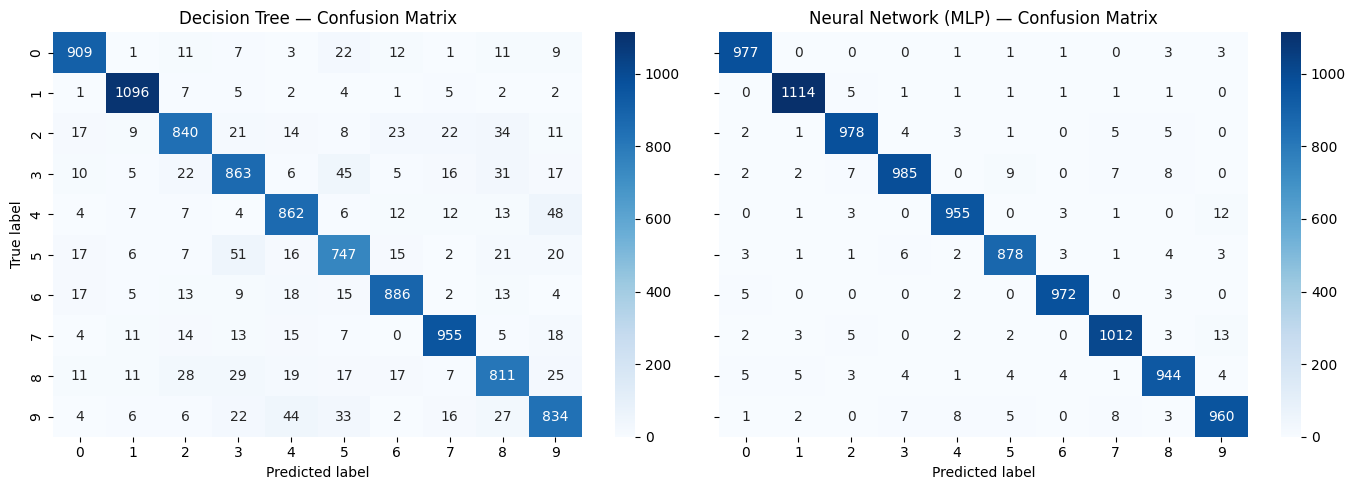

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_dt  = confusion_matrix(label_test, dt_test_pred)
cm_mlp = confusion_matrix(label_test, mlp_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Use the same color scale for both plots
vmax = max(cm_dt.max(), cm_mlp.max())
labels = list(range(10))

sns.heatmap(
    cm_dt, ax=axes[0], cmap="Blues",
    annot=True, fmt="d",
    xticklabels=labels, yticklabels=labels,
    vmin=0, vmax=vmax
)
axes[0].set_title("Decision Tree — Confusion Matrix")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

sns.heatmap(
    cm_mlp, ax=axes[1], cmap="Blues",
    annot=True, fmt="d",
    xticklabels=labels, yticklabels=labels,
    vmin=0, vmax=vmax
)
axes[1].set_title("Neural Network (MLP) — Confusion Matrix")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("")

fig.tight_layout()
plt.show()



## 6. Insights

**Decision Tree Behavior**

- The Decision Tree achieves reasonable accuracy but is limited by its axis-aligned splits.
Each split is based on a single pixel threshold, which makes it difficult to capture global digit shapes.

**Neural Network Behavior**

- The MLP significantly outperforms the Decision Tree.
By combining multiple pixels through weighted connections and non-linear activation functions,
the neural network can learn more abstract representations such as strokes and digit shapes.

## 7. Interpretation

**The classification report** summarizes precision, recall, and F1-score for each class.
Precision indicates how reliable the predictions are, while recall reflects how well each class is detected.

**The confusion matrix** provides a detailed view of class-wise errors.
Diagonal elements represent correct predictions, while off-diagonal elements highlight systematic misclassifications.
Analyzing these patterns helps identify weaknesses of the model.
